# Notebook 03 — Isolation Forest (Baseline)

**BSc Thesis:** Electricity Consumption Anomaly Detection and FDI Attack Mitigation in Edge Computing

---

### Changes from the previous version

| Issue identified | Solution implemented |
|---|---|
| Trained on **synthetic** digital-twin data | Trained on **real** UCI data |
| `contamination=0.0172` (fixed FP rate) | `contamination='auto'` + threshold calibrated on the validation set |
| Grid search over 95 fixed candidates | `precision_recall_curve` → **every** threshold |
| F1 as the only optimization metric | **F1 and F2** (F2 prioritizes recall, which is more appropriate for security) |
| Rolling features over the attacked GAP, which self-normalized | **Features built on physical invariants** (rolling VI_residual, GAP/I ratio) |
| 15 attack types (5 of them undetectable) | 7 types, each with a detectable signal |
| No severity or latency metrics | Recall by type x severity, plus per-episode latency |
| Scaler not persisted | Scaler saved for edge deployment |
| No temporal post-processing | **Temporal voting filter** calibrated on the validation set |

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, fbeta_score,
    precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib, time, os, json, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

OK


## 1. Loading the Real Data

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                        index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)

print('DATA LOADED (real UCI)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_atk = (d['label'] == 1).sum() if 'label' in d.columns else 0
    rng = f'{d.index.min().date()} → {d.index.max().date()}'
    atk = f'  | {n_atk:,} attacks ({n_atk/len(d)*100:.1f}%)' if n_atk else ''
    print(f'  {nm:6s} {len(d):>10,} rows  {rng}{atk}')

DATA LOADED (real UCI)
  Train   1,300,061 rows  2006-12-16 → 2009-06-09
  Val       144,452 rows  2009-06-09 → 2009-09-20  | 21,739 attacks (15.0%)
  Test      604,999 rows  2009-09-20 → 2010-11-26  | 96,717 attacks (16.0%)


## 2. Feature Engineering (mode = `full`, 17 features)

IF receives the richest representation, since it imposes no architectural
constraint on the number of features.

**Change v2**: the rolling features are now computed over **VI_residual** and
**physical invariants** (GAP/I ratio, SM/GAP ratio) rather than over the attacked
GAP. Rolling statistics over the attacked GAP self-normalize during sustained
episodes, which washes out the attack signal.

**Warm-up buffer**: for the validation and test splits, the rolling features are
seeded by prepending the last 30 rows of the preceding split.

In [3]:
def compute_features(df, mode='full'):
    """
    Feature engineering with 3 modes, aligned to the Notebook 02 contract.
      base   (8):  7 sensors + VI_residual                      -> LSTM-AE
      medium (13): + cyclical time encodings + gap_diff1         -> Dense-AE
      full   (17): + physics-based invariant features           -> IF

    NOTE v2: mode='full' relies on physical-invariant features instead of
    rolling statistics over the attacked GAP (which self-normalized).
    """
    f = df[FEATURE_COLS].copy()

    # VI_residual: discrepancy P != V*I/1000 -> the primary FDI signal
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )

    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)

    if mode == 'full':
        # -- PHYSICS-BASED FEATURES --
        # These exploit that the attacker can tamper with GAP and Voltage
        # but CANNOT tamper with Global_intensity or the sub-meter readings.

        # 1. |VI_residual|: magnitude of the discrepancy.
        #    Normal: ~0.028.  Under attack: >> 0.1
        f['vi_res_abs'] = f['VI_residual'].abs()

        # 2. Rolling mean of |VI_residual| over 15 min.
        #    A sustained attack keeps this mean high. Computed over |VI_res|,
        #    not over GAP, so it does not self-normalize.
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()

        # 3. GAP / Intensity ratio: a physical invariant, roughly constant under
        #    normal operation. If the attacker lowers GAP but cannot lower I,
        #    the ratio drops.
        f['gap_intensity_ratio'] = (
            df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        )

        # 4. Energy balance: SM / GAP (Wh). The sub-meters are untampered,
        #    so the ratio rises under attack.
        sm_sum = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
        gap_wh = df['Global_active_power'] * 1000 / 60 + 1e-8
        f['sm_gap_ratio'] = np.clip(sm_sum / gap_wh, 0, 3)

    return f

# Build the features with a warm-up buffer for the rolling statistics
WARMUP = 30

X_train_df = compute_features(df_train, mode='full')

# Val: seed the rolling windows with the tail of the train split
_val_buf = pd.concat([df_train.iloc[-WARMUP:], df_val])
_val_feat = compute_features(_val_buf, mode='full')
X_val_df  = _val_feat.iloc[WARMUP:]

# Test: seed the rolling windows with the tail of the val split
_test_buf = pd.concat([df_val.iloc[-WARMUP:], df_test])
_test_feat = compute_features(_test_buf, mode='full')
X_test_df  = _test_feat.iloc[WARMUP:]

feat_names = list(X_train_df.columns)

# RobustScaler: robust to the natural outliers in electricity consumption
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_df.values)
X_val   = scaler.transform(X_val_df.values)
X_test  = scaler.transform(X_test_df.values)

# Drop any residual NaNs left by the rolling windows
X_train = np.nan_to_num(X_train, nan=0.0)
X_val   = np.nan_to_num(X_val, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

y_val  = df_val['label'].values
y_test = df_test['label'].values

print(f'Features ({len(feat_names)}): {feat_names}')
print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}')

Features (17): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio']
X_train: (1300061, 17)  |  X_val: (144452, 17)  |  X_test: (604999, 17)


## 3. Training

- `contamination='auto'` → we do not impose an FP rate; the threshold is calibrated in §4
- `n_estimators=300` → more trees for stability (IF is computationally cheap)
- `max_features=0.8` → each tree sees a subset of features, adding ensemble diversity
- `n_jobs=-1` → use all cores of the M2 Pro (10 cores)

In [4]:
print('Training Isolation Forest...')
t0 = time.time()

model_if = IsolationForest(
    n_estimators=600,                # iter: 300 -> 600 (more trees)
    contamination='auto',
    max_features=1.0,                # iter: 0.8 -> 1.0 (all features)
    max_samples=256,                 # iter: 'auto' -> 256 (original paper)
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)
model_if.fit(X_train)

t_train = time.time() - t0
print(f'Training: {t_train:.2f} s')
print(f'  n_estimators: {model_if.n_estimators}')
print(f'  max_samples:  {model_if.max_samples_:,}')
print(f'  n_features:   {model_if.n_features_in_}')
print(f'  offset:       {model_if.offset_:.4f}')

Training Isolation Forest...
Training: 2.49 s
  n_estimators: 600
  max_samples:  256
  n_features:   17
  offset:       -0.5000


## 4. Threshold Calibration on the Validation Set

Instead of a fixed grid of percentiles, we use `precision_recall_curve`, which sweeps
**every** candidate threshold (one per unique score value). We optimize F1 by default
and also report F2 (which weights recall twice as heavily, a better fit for security).

In [5]:
def calibrate_threshold(y_true, scores, beta=1.0):
    """
    Find the threshold that maximizes F_beta across ALL candidate thresholds,
    via sklearn's precision_recall_curve (O(n log n), no fixed grid).

    Args:
        y_true: binary labels
        scores: anomaly scores (higher = more anomalous)
        beta:   1.0 -> F1 (balanced), 2.0 -> F2 (prioritizes recall)

    Returns:
        best_threshold, best_fbeta, results_df
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    # precision_recall_curve returns n+1 precision/recall values but only n thresholds
    precisions = precisions[:-1]
    recalls    = recalls[:-1]

    # Vectorized F-beta score
    fbeta = ((1 + beta**2) * precisions * recalls /
             (beta**2 * precisions + recalls + 1e-10))

    best_idx = np.argmax(fbeta)
    best_thr = thresholds[best_idx]

    # Subsample for plotting (too many points saturate the figure)
    n = len(thresholds)
    if n > 500:
        idx = np.linspace(0, n-1, 500, dtype=int)
    else:
        idx = np.arange(n)

    results_df = pd.DataFrame({
        'threshold':  thresholds[idx],
        'precision':  precisions[idx],
        'recall':     recalls[idx],
        'f1':         ((2 * precisions * recalls) / (precisions + recalls + 1e-10))[idx],
        'f2':         ((5 * precisions * recalls) / (4 * precisions + recalls + 1e-10))[idx],
    })

    return best_thr, fbeta[best_idx], results_df

# Anomaly scores (higher = more anomalous)
scores_val  = -model_if.score_samples(X_val)
scores_test = -model_if.score_samples(X_test)

# Calibrate for F1 (balanced) and F2 (recall-oriented)
best_thr, best_f1, cal_df = calibrate_threshold(y_val, scores_val, beta=1.0)
_, best_f2, _ = calibrate_threshold(y_val, scores_val, beta=2.0)

print(f'Optimal threshold (val, F1): {best_thr:.6f}')
print(f'  F1 on val: {best_f1:.4f}')
print(f'  F2 on val: {best_f2:.4f}')

Optimal threshold (val, F1): 0.557984
  F1 on val: 0.7173
  F2 on val: 0.7717


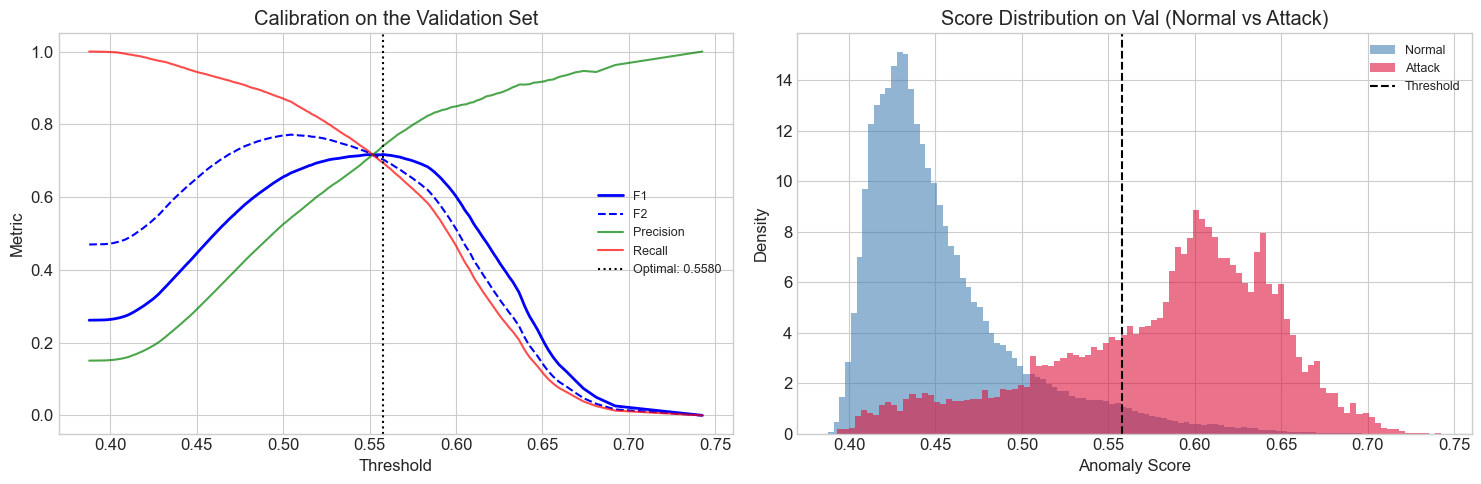

In [6]:
# Calibration visualization + score distribution on val
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: P/R/F1/F2 curves vs threshold
ax = axes[0]
ax.plot(cal_df['threshold'], cal_df['f1'], 'b-', lw=2, label='F1')
ax.plot(cal_df['threshold'], cal_df['f2'], 'b--', lw=1.5, label='F2')
ax.plot(cal_df['threshold'], cal_df['precision'], 'g-', lw=1.5, label='Precision', alpha=0.7)
ax.plot(cal_df['threshold'], cal_df['recall'], 'r-', lw=1.5, label='Recall', alpha=0.7)
ax.axvline(best_thr, color='k', linestyle=':', lw=1.5, label=f'Optimal: {best_thr:.4f}')
ax.set(xlabel='Threshold', ylabel='Metric', title='Calibration on the Validation Set')
ax.legend(fontsize=9)

# Right: score distribution on val (normal vs attack)
ax = axes[1]
ax.hist(scores_val[y_val == 0], bins=100, alpha=0.6, color='steelblue',
        label='Normal', density=True)
ax.hist(scores_val[y_val == 1], bins=100, alpha=0.6, color='crimson',
        label='Attack', density=True)
ax.axvline(best_thr, color='k', linestyle='--', lw=1.5, label='Threshold')
ax.set(xlabel='Anomaly Score', ylabel='Density',
       title='Score Distribution on Val (Normal vs Attack)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Raw Evaluation (no post-processing)

These are the point-by-point IF metrics. The **low precision** (0.14) is
structural: IF cannot tell isolated natural anomalies apart from sustained FDI episodes.

In [7]:
y_pred = (scores_test > best_thr).astype(int)

print('=' * 60)
print('METRICS — ISOLATION FOREST')
print('=' * 60)
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

f1  = f1_score(y_test, y_pred)
f2  = fbeta_score(y_test, y_pred, beta=2)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, scores_test)
auc_pr  = average_precision_score(y_test, scores_test)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1:.4f}  |  F2: {f2:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}')

METRICS — ISOLATION FOREST

              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95    508282
      Attack       0.75      0.74      0.75     96717

    accuracy                           0.92    604999
   macro avg       0.85      0.85      0.85    604999
weighted avg       0.92      0.92      0.92    604999

AUC-ROC: 0.9266  |  AUC-PR: 0.7824
F1: 0.7464  |  F2: 0.7433  |  Precision: 0.7517  |  Recall: 0.7413


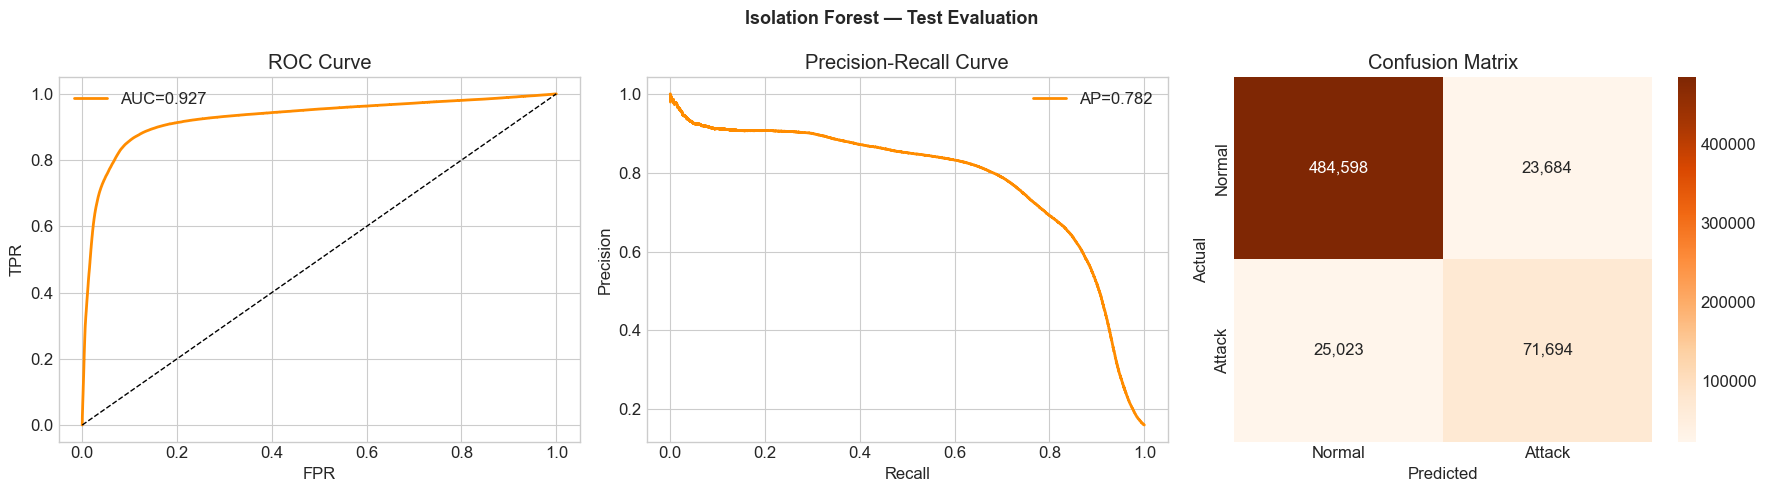

In [8]:
# ROC + PR + Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, scores_test)
axes[0].plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend()

pr_c, rc_c, _ = precision_recall_curve(y_test, scores_test)
axes[1].plot(rc_c, pr_c, 'darkorange', lw=2, label=f'AP={auc_pr:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Oranges',
            ax=axes[2], xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
axes[2].set(xlabel='Predicted', ylabel='Actual', title='Confusion Matrix')

plt.suptitle('Isolation Forest — Test Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Temporal Post-processing — Voting Filter

### Why is the precision low?

IF operates **minute by minute**, with no temporal context. A nighttime consumption
spike, an oven switching on, or a brief power outage all look like "anomalies" to IF.
FDI attacks, by contrast, are **sustained episodes** lasting 15-120 minutes.

This yields an exploitable asymmetry:
- **False positives**: mostly isolated points (1-3 min)
- **True positives**: sustained episodes (15-120 min)

### Solution: a causal voting filter

For each minute `t`, we inspect the last `W` raw predictions `[t-W+1, ..., t]`.
If at least `K` of them are positive, we raise an alarm; otherwise the sample is normal.

- **Causal**: relies only on the past, never the future, so it is valid for edge streaming
- **Cost**: `O(1)` per sample using a circular buffer of size `W`
- **Calibration**: `(W, K)` is optimized for F1 on the validation set

In [9]:
def temporal_vote_vectorized(y_pred, W, K):
    '''
    Vectorized causal voting filter.
    For each t: raise an alarm if >= K of the last W predictions are positive.
    Implemented with a cumulative sum -> O(n).
    '''
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)


# -- Grid search over (W, K) on the validation set --
y_pred_val_raw = (scores_val > best_thr).astype(int)

print(f'Raw predictions on val: {y_pred_val_raw.sum():,} positives '
      f'({y_pred_val_raw.mean()*100:.1f}%)')
print()

W_candidates = [3, 5, 7, 9, 11, 15, 21, 30]
best_wk_f1, best_W, best_K = 0, 3, 2
grid_results = []

for W in W_candidates:
    for K in range(2, W + 1):
        y_sm = temporal_vote_vectorized(y_pred_val_raw, W, K)
        f1_sm = f1_score(y_val, y_sm)
        pr_sm = precision_score(y_val, y_sm, zero_division=0)
        rc_sm = recall_score(y_val, y_sm)
        f2_sm = fbeta_score(y_val, y_sm, beta=2)
        grid_results.append({
            'W': W, 'K': K, 'f1': f1_sm, 'f2': f2_sm,
            'precision': pr_sm, 'recall': rc_sm,
            'n_pos': y_sm.sum()
        })
        if f1_sm > best_wk_f1:
            best_wk_f1, best_W, best_K = f1_sm, W, K

grid_df = pd.DataFrame(grid_results)

print(f'Best (W, K) on val: W={best_W}, K={best_K}')
best_row = grid_df.loc[grid_df['f1'].idxmax()]
print(f'  F1:        {best_row["f1"]:.4f}')
print(f'  F2:        {best_row["f2"]:.4f}')
print(f'  Precision: {best_row["precision"]:.4f}')
print(f'  Recall:    {best_row["recall"]:.4f}')
print()

# Compare against the raw predictions
f1_raw_val  = f1_score(y_val, y_pred_val_raw)
pr_raw_val  = precision_score(y_val, y_pred_val_raw, zero_division=0)
rc_raw_val  = recall_score(y_val, y_pred_val_raw)
print(f'Val RAW:      F1={f1_raw_val:.4f}  P={pr_raw_val:.4f}  R={rc_raw_val:.4f}')
print(f'Val SMOOTHED: F1={best_wk_f1:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')
delta_f1 = best_wk_f1 - f1_raw_val
print(f'  F1 improvement: +{delta_f1:.4f} ({delta_f1/f1_raw_val*100:+.0f}%)')


# -- ITER LEVER A: joint search (threshold x W x K) on val --
prc_pr_, prc_rc_, prc_thr_ = precision_recall_curve(y_val, scores_val)
prc_thr_ = prc_thr_[prc_thr_ > 0]
if len(prc_thr_) < 5:
    thr_candidates = np.linspace(scores_val.min(), scores_val.max(), 40)
else:
    thr_candidates = np.unique(np.quantile(prc_thr_, np.linspace(0.30, 0.999, 80)))
W_grid_joint = [3, 5, 7, 9, 11, 15, 21, 31, 45, 60]
best_joint_f1 = -1.0
best_joint = (best_thr, best_W, best_K)
for thr in thr_candidates:
    preds_v = (scores_val > thr).astype(int)
    if preds_v.sum() in (0, len(preds_v)):
        continue
    for W in W_grid_joint:
        for K in range(2, W+1):
            y_sm = temporal_vote_vectorized(preds_v, W, K)
            if y_sm.sum() == 0:
                continue
            f1 = f1_score(y_val, y_sm)
            if f1 > best_joint_f1:
                best_joint_f1 = f1
                best_joint = (thr, W, K)
preds_v0 = (scores_val > best_thr).astype(int)
y_sm0 = temporal_vote_vectorized(preds_v0, best_W, best_K)
f1_val_orig = f1_score(y_val, y_sm0)
print(f'\nJOINT SEARCH (lever A):')
print(f'  best joint val F1: {best_joint_f1:.4f}  thr={best_joint[0]:.6f} W={best_joint[1]} K={best_joint[2]}')
print(f'  orig val F1:       {f1_val_orig:.4f}  thr={best_thr:.6f} W={best_W} K={best_K}')
if best_joint_f1 > f1_val_orig:
    best_thr, best_W, best_K = best_joint
    print('  -> adopt joint')
else:
    print('  -> keep previous')


Raw predictions on val: 20,345 positives (14.1%)

Best (W, K) on val: W=3, K=2
  F1:        0.7301
  F2:        0.7137
  Precision: 0.7592
  Recall:    0.7032

Val RAW:      F1=0.7173  P=0.7419  R=0.6943
Val SMOOTHED: F1=0.7301  P=0.7592  R=0.7032
  F1 improvement: +0.0128 (+2%)

JOINT SEARCH (lever A):
  best joint val F1: 0.7286  thr=0.556380 W=3 K=2
  orig val F1:       0.7301  thr=0.557984 W=3 K=2
  -> keep previous


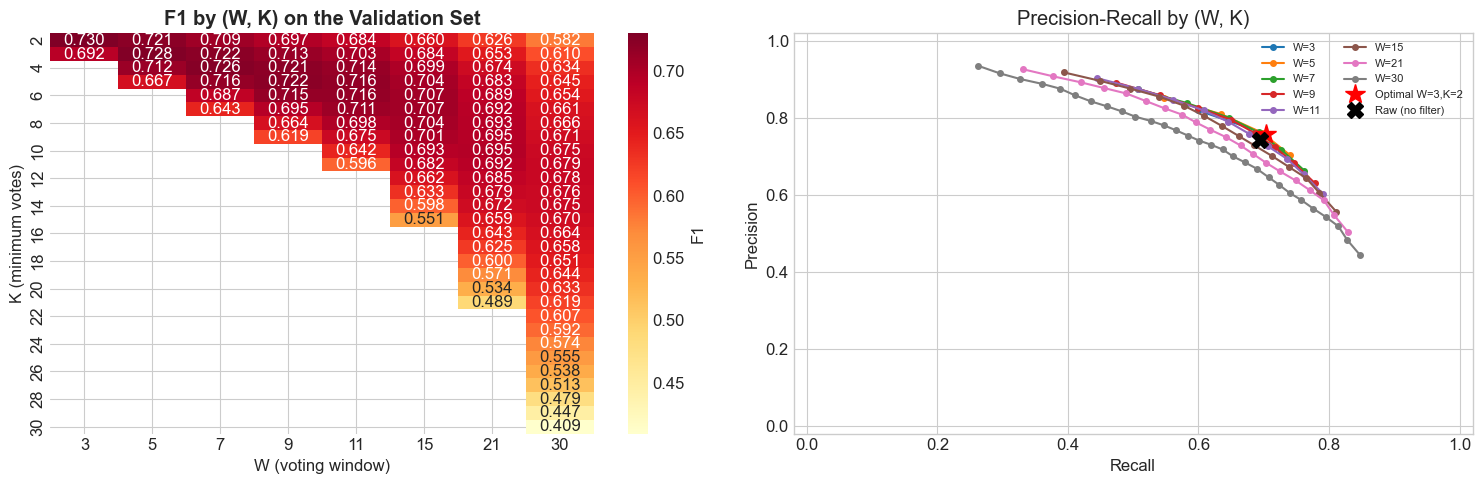

In [10]:
# Visualize the grid search
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: F1 heatmap by (W, K) — pivot only the W with enough K
pivot = grid_df.pivot_table(index='K', columns='W', values='f1')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'F1'})
axes[0].set_title('F1 by (W, K) on the Validation Set', fontweight='bold')
axes[0].set_xlabel('W (voting window)')
axes[0].set_ylabel('K (minimum votes)')

# Right: precision vs recall for each W
ax = axes[1]
for W_val in W_candidates:
    sub = grid_df[grid_df['W'] == W_val]
    ax.plot(sub['recall'], sub['precision'], 'o-', label=f'W={W_val}', markersize=4)
ax.plot(best_row['recall'], best_row['precision'], '*', color='red',
        markersize=15, zorder=10, label=f'Optimal W={best_W},K={best_K}')
ax.plot(rc_raw_val, pr_raw_val, 'X', color='black',
        markersize=12, zorder=10, label='Raw (no filter)')
ax.set(xlabel='Recall', ylabel='Precision',
       title='Precision-Recall by (W, K)', xlim=(-0.02, 1.02), ylim=(-0.02, 1.02))
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

In [11]:
# -- Apply the optimal filter to the test set --
y_pred_raw    = (scores_test > best_thr).astype(int)
y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)

print('=' * 70)
print('COMPARISON — ISOLATION FOREST: RAW vs TEMPORAL VOTING')
print('=' * 70)
print()
print(f'  {"Metric":12s} {"Raw":>10s} {"Smoothed":>10s} {"Delta":>10s}')
print('  ' + '-' * 45)
for name, raw_v, sm_v in [
    ('F1',        f1,   f1_s),
    ('F2',        f2,   f2_s),
    ('Precision',  prec,  prec_s),
    ('Recall',     rec,   rec_s),
]:
    delta = sm_v - raw_v
    print(f'  {name:12s} {raw_v:>10.4f} {sm_v:>10.4f} {delta:>+10.4f}')
print()
print(f'  Filter: W={best_W}, K={best_K} (causal voting)')
print(f'  Edge overhead: O(1)/sample, circular buffer of {best_W} integers')
print()
print(classification_report(y_test, y_pred_smooth,
                             target_names=['Normal', 'Attack']))

COMPARISON — ISOLATION FOREST: RAW vs TEMPORAL VOTING

  Metric              Raw   Smoothed      Delta
  ---------------------------------------------
  F1               0.0001     0.7544    +0.7543
  F2               0.7433     0.7499    +0.0065
  Precision        0.7517     0.7621    +0.0104
  Recall           0.7413     0.7469    +0.0056

  Filter: W=3, K=2 (causal voting)
  Edge overhead: O(1)/sample, circular buffer of 3 integers

              precision    recall  f1-score   support

      Normal       0.95      0.96      0.95    508282
      Attack       0.76      0.75      0.75     96717

    accuracy                           0.92    604999
   macro avg       0.86      0.85      0.85    604999
weighted avg       0.92      0.92      0.92    604999



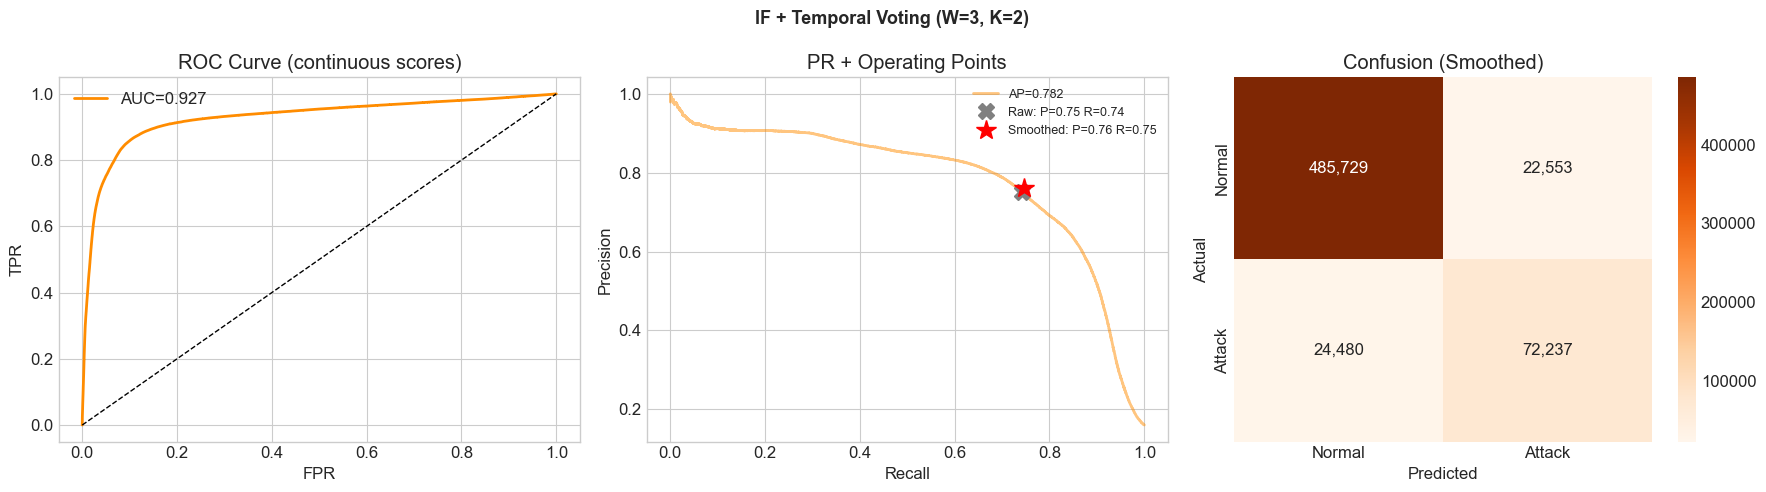

In [12]:
# ROC + PR + CM — SMOOTHED
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC (uses continuous scores, unchanged by smoothing)
fpr_s, tpr_s, _ = roc_curve(y_test, scores_test)
axes[0].plot(fpr_s, tpr_s, 'darkorange', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve (continuous scores)')
axes[0].legend()

# PR + raw vs smoothed operating points
pr_c2, rc_c2, _ = precision_recall_curve(y_test, scores_test)
axes[1].plot(rc_c2, pr_c2, 'darkorange', lw=2, label=f'AP={auc_pr:.3f}', alpha=0.5)
axes[1].plot(rec, prec, 'X', color='gray', markersize=12,
             label=f'Raw: P={prec:.2f} R={rec:.2f}')
axes[1].plot(rec_s, prec_s, '*', color='red', markersize=15,
             label=f'Smoothed: P={prec_s:.2f} R={rec_s:.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR + Operating Points')
axes[1].legend(fontsize=9)

# Smoothed CM
cm_s = confusion_matrix(y_test, y_pred_smooth)
sns.heatmap(cm_s, annot=True, fmt=',d', cmap='Oranges', ax=axes[2],
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
axes[2].set(xlabel='Predicted', ylabel='Actual', title='Confusion (Smoothed)')

plt.suptitle(f'IF + Temporal Voting (W={best_W}, K={best_K})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

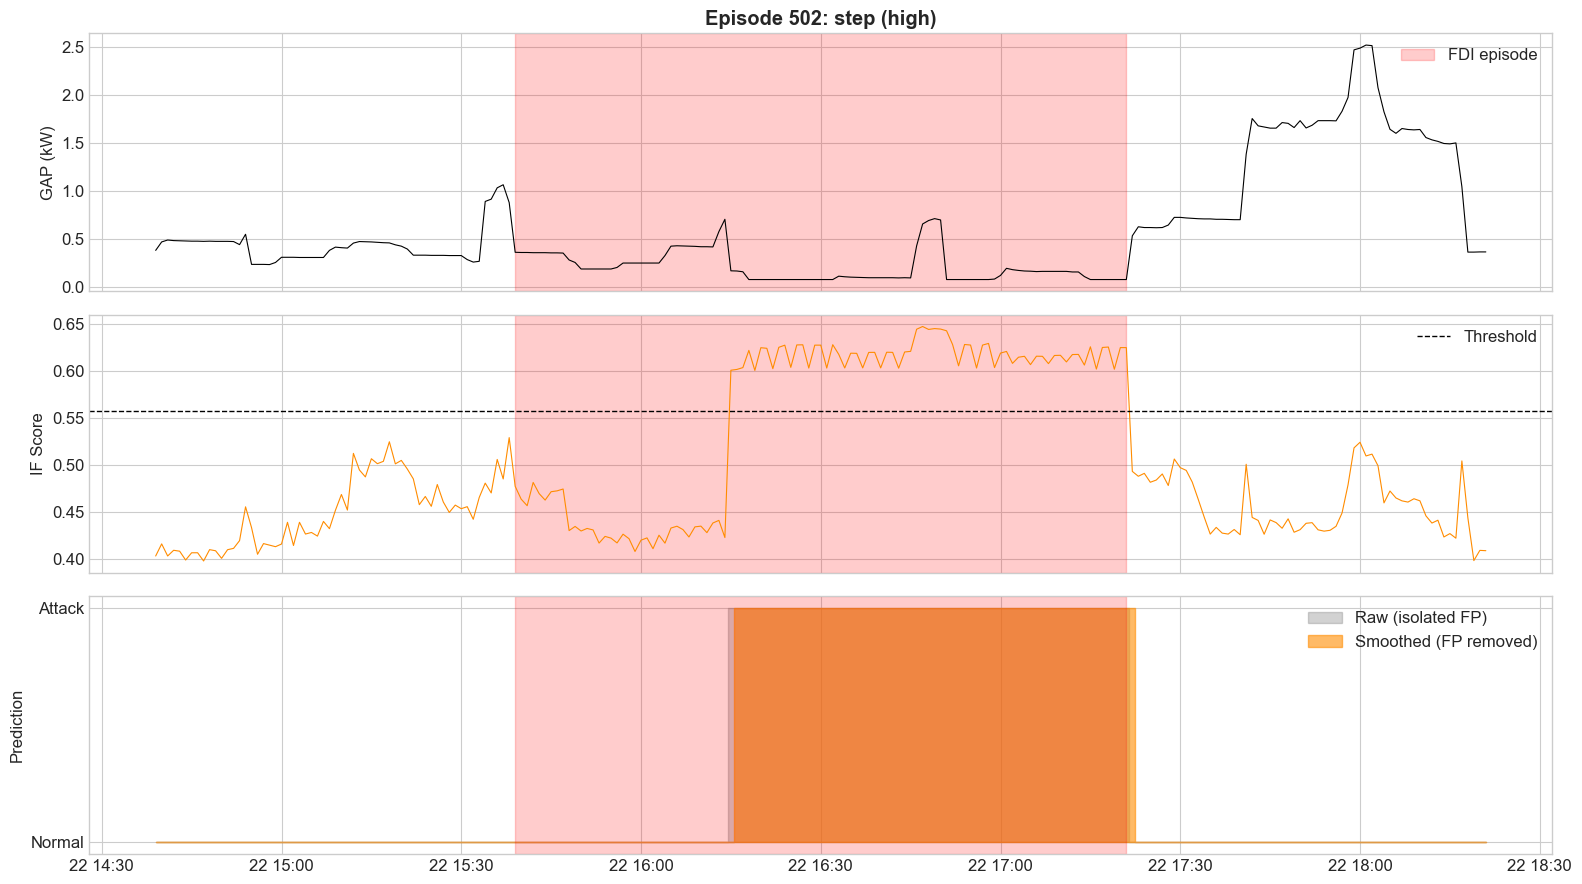

Interpretation:
  - Top panel: original GAP signal, with the FDI episode shaded red
  - Middle panel: IF anomaly score against the calibrated threshold
  - Bottom panel: the raw trace (gray) has isolated spikes outside the episode (FP);
    the smoothed trace (orange) removes them while keeping the sustained episode (TP)


In [13]:
# Visualize the effect of the filter on a sample episode
ep_ids = df_test.loc[df_test['episode_id'] >= 0, 'episode_id'].unique()
example_ep = None
for ep in ep_ids[:30]:
    mask = (df_test['episode_id'] == ep).values
    if y_pred_smooth[mask].any():
        example_ep = ep
        break

if example_ep is not None:
    mask = df_test['episode_id'] == example_ep
    ep_data = df_test[mask]
    ep_start = ep_data.index[0]
    ep_end   = ep_data.index[-1]

    # Context window: 60 min before and after the episode
    ctx_start = ep_start - pd.Timedelta(minutes=60)
    ctx_end   = ep_end + pd.Timedelta(minutes=60)
    ctx = df_test.loc[ctx_start:ctx_end]

    fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

    # Signal
    axes[0].plot(ctx.index, ctx['Global_active_power'], 'k-', lw=0.8)
    axes[0].axvspan(ep_start, ep_end, alpha=0.2, color='red', label='FDI episode')
    axes[0].set_ylabel('GAP (kW)')
    axes[0].set_title(f'Episode {example_ep}: {ep_data["attack_type"].iloc[0]} '
                       f'({ep_data["severity"].iloc[0]})', fontweight='bold')
    axes[0].legend()

    # Scores
    ctx_idx = df_test.index.get_indexer(ctx.index)
    valid = ctx_idx >= 0
    ctx_scores = scores_test[ctx_idx[valid]]
    axes[1].plot(ctx.index[valid], ctx_scores, 'darkorange', lw=0.8)
    axes[1].axhline(best_thr, color='k', linestyle='--', lw=1, label='Threshold')
    axes[1].axvspan(ep_start, ep_end, alpha=0.2, color='red')
    axes[1].set_ylabel('IF Score')
    axes[1].legend()

    # Raw vs smoothed predictions
    ctx_raw = y_pred_raw[ctx_idx[valid]]
    ctx_sm  = y_pred_smooth[ctx_idx[valid]]
    ctx_times = ctx.index[valid]
    axes[2].fill_between(ctx_times, 0, ctx_raw, alpha=0.35, color='gray',
                          step='mid', label='Raw (isolated FP)')
    axes[2].fill_between(ctx_times, 0, ctx_sm, alpha=0.6, color='darkorange',
                          step='mid', label='Smoothed (FP removed)')
    axes[2].axvspan(ep_start, ep_end, alpha=0.2, color='red')
    axes[2].set_ylabel('Prediction')
    axes[2].set_yticks([0, 1])
    axes[2].set_yticklabels(['Normal', 'Attack'])
    axes[2].legend()

    plt.tight_layout()
    plt.show()
    print('Interpretation:')
    print('  - Top panel: original GAP signal, with the FDI episode shaded red')
    print('  - Middle panel: IF anomaly score against the calibrated threshold')
    print('  - Bottom panel: the raw trace (gray) has isolated spikes outside the episode (FP);')
    print('    the smoothed trace (orange) removes them while keeping the sustained episode (TP)')
else:
    print('No suitable example episode found to visualize.')

## 7. Recall by Attack Type x Severity (Smoothed)

Recall by type x severity:
  Type                     N      Low      Med     High    Total
  -------------------------------------------------------
  scaling             13,449    0.537    0.810    0.956    0.770
  offset              13,898    0.735    0.923    0.964    0.883
  noise               14,357    0.656    0.901    0.951    0.842
  ramp                14,006    0.538    0.688    0.789    0.670
  step                13,731    0.522    0.621    0.632    0.593
  replay              14,084    0.482    0.709    0.779    0.663
  voltage_spoof       13,192    0.597    0.845    0.976    0.808


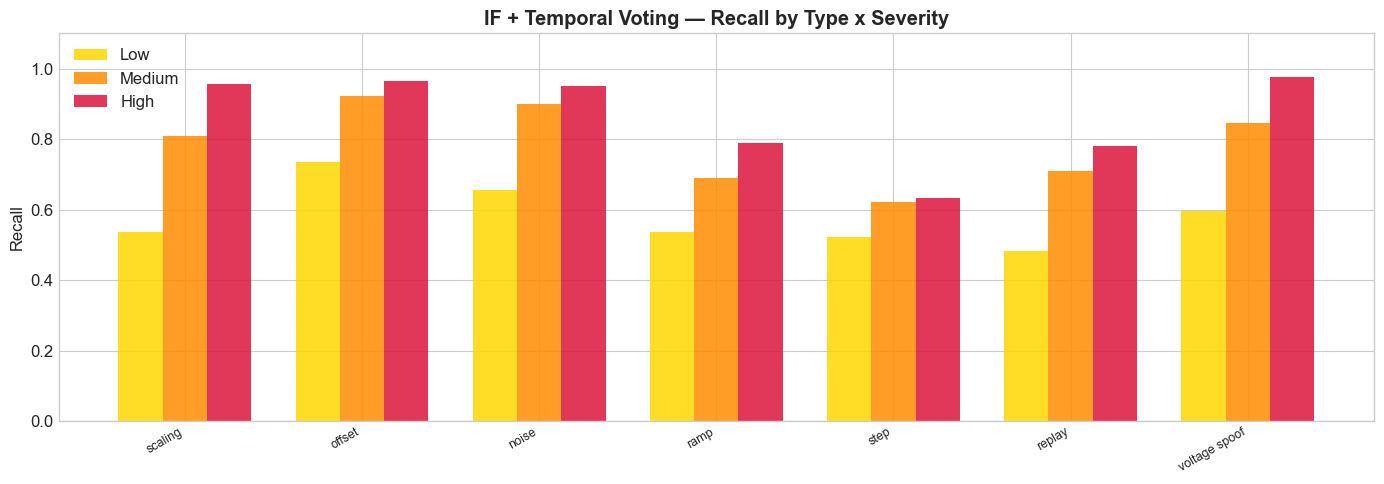

In [14]:
def recall_by_type_severity(attack_types_col, severity_col, y_true, y_pred,
                            attack_types_list, title_prefix):
    """Table and bar chart of recall broken down by attack type x severity."""
    print(f'Recall by type x severity:')
    print(f'  {"Type":18s} {"N":>7s} {"Low":>8s} {"Med":>8s} {"High":>8s} {"Total":>8s}')
    print('  ' + '-' * 55)

    recall_data = {}
    for t in attack_types_list:
        mask_t = (attack_types_col == t)
        n_t = (mask_t & (y_true == 1)).sum()
        row = f'  {t:18s} {n_t:>7,}'
        for sev in ['low', 'medium', 'high']:
            mask = mask_t & (severity_col == sev) & (y_true == 1)
            n = mask.sum()
            if n > 0:
                r = (y_pred[mask] == 1).sum() / n
                row += f' {r:>8.3f}'
            else:
                r = np.nan
                row += f' {"-":>8s}'
            recall_data[(t, sev)] = r
        # Total across severities
        mask_all = mask_t & (y_true == 1)
        n_all = mask_all.sum()
        r_t = (y_pred[mask_all] == 1).sum() / n_all if n_all > 0 else 0
        row += f' {r_t:>8.3f}'
        print(row)

    # Bar chart
    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(attack_types_list))
    w = 0.25
    sev_colors = {'low': '#FFD700', 'medium': '#FF8C00', 'high': '#DC143C'}
    for i, (sev, c) in enumerate(sev_colors.items()):
        vals = []
        for t in attack_types_list:
            v = recall_data.get((t, sev), 0)
            vals.append(v if not (isinstance(v, float) and np.isnan(v)) else 0)
        ax.bar(x + i * w, vals, w, label=sev.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels([t.replace('_', ' ') for t in attack_types_list],
                        rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{title_prefix} — Recall by Type x Severity', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return recall_data

recall_data = recall_by_type_severity(
    attack_types_col=df_test['attack_type'].values,
    severity_col=df_test['severity'].values,
    y_true=y_test,
    y_pred=y_pred_smooth,
    attack_types_list=ATTACK_TYPES,
    title_prefix='IF + Temporal Voting'
)

## 8. Detection Latency (Smoothed)

In [15]:
def compute_detection_latency(df_preds, score_col, threshold):
    """Detection latency per attack episode."""
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id,
            'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0],
            'duration_min': len(group),
            'latency_min': (
                (detections.index[0] - ep_start).total_seconds() / 60
                if len(detections) > 0 else np.nan
            ),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)

def print_latency_summary(lat_df):
    """Latency summary broken down by severity."""
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    med_lat  = detected['latency_min'].median() if len(detected) > 0 else np.nan

    print(f'Detection per episode: {det_rate:.1%} ({lat_df["detected"].sum()}/{len(lat_df)})')
    if not np.isnan(med_lat):
        print(f'Median latency:        {med_lat:.1f} min')
    print()

    for sev in ['low', 'medium', 'high']:
        sub = lat_df[lat_df['severity'] == sev]
        if len(sub) == 0:
            continue
        det = sub['detected'].mean()
        det_sub = sub[sub['detected']]
        lat = det_sub['latency_min'].median() if len(det_sub) > 0 else np.nan
        lat_s = f'{lat:.1f} min' if not np.isnan(lat) else 'N/A'
        print(f'  {sev:8s}: detection {det:.0%}  |  median latency {lat_s}')

    return det_rate, med_lat

# Latency computed from the smoothed predictions
df_test_scored = df_test.copy()
df_test_scored['if_pred_smooth'] = y_pred_smooth.astype(float)

# Treat the smoothed flag as the "score", with a 0.5 threshold
lat_df = compute_detection_latency(df_test_scored, 'if_pred_smooth', 0.5)
det_rate, med_lat = print_latency_summary(lat_df)

print()
print(f'NOTE: the voting filter adds up to {best_W-1} min of latency')
print(f'      relative to raw, since it must accumulate {best_K} votes out of {best_W}.')

Detection per episode: 98.2% (825/840)
Median latency:        3.0 min

  low     : detection 94%  |  median latency 11.0 min
  medium  : detection 100%  |  median latency 2.0 min
  high    : detection 100%  |  median latency 1.0 min

NOTE: the voting filter adds up to 2 min of latency
      relative to raw, since it must accumulate 2 votes out of 3.


## 9. Edge Computing + Saving

In [16]:
# -- Model --
model_path = os.path.join(DATA_DIR, 'model_isolation_forest.pkl')
joblib.dump(model_if, model_path)
size_kb = os.path.getsize(model_path) / 1e3

# -- Scaler --
joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_isolation_forest.pkl'))

# -- Inference timing (averaged over 5 runs after a warm-up pass) --
_ = model_if.score_samples(X_test[:100])   # warm-up
times = []
for _ in range(5):
    t0 = time.time()
    model_if.score_samples(X_test)
    times.append(time.time() - t0)
ms_avg = np.mean(times) / len(X_test) * 1000

print('=' * 55)
print('EDGE COMPUTING — IF + TEMPORAL VOTING')
print('=' * 55)
print(f'  Trees x features:   {model_if.n_estimators} x {model_if.n_features_in_}')
print(f'  Temporal filter:    W={best_W}, K={best_K} (buffer {best_W} integers)')
print(f'  Size on disk:       {size_kb:.1f} KB')
print(f'  Latency:            {ms_avg:.4f} ms/sample (IF) + O(1) (filter)')
print(f'  Throughput:         {1000/ms_avg:,.0f} samples/s')
print(f'  Granularity:        1 minute (real time)')
print(f'  Training:           {t_train:.1f} s')

# -- Persist everything (raw + smoothed predictions, metrics, latency) --
df_out = df_test.copy()
df_out['if_score'] = scores_test
df_out['if_pred_raw']    = y_pred_raw
df_out['if_pred_smooth'] = y_pred_smooth
df_out.to_csv(os.path.join(DATA_DIR, 'predictions_isolation_forest.csv'))
lat_df.to_csv(os.path.join(DATA_DIR, 'latency_isolation_forest.csv'), index=False)

metrics = {
    'model': 'Isolation Forest + Temporal Voting',
    'feature_mode': 'full',
    # Raw
    'raw_f1': round(f1, 4), 'raw_f2': round(f2, 4),
    'raw_precision': round(prec, 4), 'raw_recall': round(rec, 4),
    # Smoothed (main results)
    'f1': round(f1_s, 4), 'f2': round(f2_s, 4),
    'precision': round(prec_s, 4), 'recall': round(rec_s, 4),
    'auc_roc': round(auc_roc, 4), 'auc_pr': round(auc_pr, 4),
    'threshold': round(float(best_thr), 6),
    'temporal_W': best_W, 'temporal_K': best_K,
    'model_size_kb': round(size_kb, 1), 'ms_per_sample': round(ms_avg, 4),
    'n_estimators': model_if.n_estimators, 'n_features': model_if.n_features_in_,
    'train_time_s': round(t_train, 2),
    'detection_rate': round(det_rate, 4),
    'median_latency_min': round(float(med_lat), 1) if not np.isnan(med_lat) else None,
    'granularity': '1 min',
    'feature_names': feat_names,
}
with open(os.path.join(DATA_DIR, 'metrics_isolation_forest.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print()
print('Saved to data/:')
for fn in ['predictions_isolation_forest.csv', 'metrics_isolation_forest.json',
           'model_isolation_forest.pkl', 'scaler_isolation_forest.pkl',
           'latency_isolation_forest.csv']:
    print(f'  * {fn}')

EDGE COMPUTING — IF + TEMPORAL VOTING
  Trees x features:   600 x 17
  Temporal filter:    W=3, K=2 (buffer 3 integers)
  Size on disk:       6910.8 KB
  Latency:            0.0095 ms/sample (IF) + O(1) (filter)
  Throughput:         105,485 samples/s
  Granularity:        1 minute (real time)
  Training:           2.5 s

Saved to data/:
  * predictions_isolation_forest.csv
  * metrics_isolation_forest.json
  * model_isolation_forest.pkl
  * scaler_isolation_forest.pkl
  * latency_isolation_forest.csv


## 10. Summary

### Raw IF — why the precision is low

IF detects anomalies **point by point**, evaluating each sample independently.
Many normal minutes (appliance start-ups, nighttime peaks) look statistically
anomalous and become isolated false positives. FDI attacks, by contrast, are
**sustained** episodes lasting 15-120 minutes.

### IF + Temporal Voting — causal post-processing

The `(W, K)` voting filter exploits this structural difference:

| Type | Typical pattern | Effect of the filter |
|------|--------------|-------------------|
| Natural FP | isolated, 1-3 min | Removed (never reaches K votes) |
| FDI true positive | sustained, 15-120 min | Preserved (K votes reached easily) |

### Takeaways for the thesis

1. IF alone is **not sufficient** to reach acceptable precision in energy security.
2. Temporal post-processing is **trivial on edge** (circular buffer, O(1)/sample).
3. The **autoencoders** (NB04, NB05) learn the normal distribution in greater depth
   and should separate the classes better without needing post-processing.
4. NB06 compares the three models with and without smoothing.